# Extract context-specific region embeddings from ChromBERT

In [3]:
# ChromBERT-tools API Examples
# 
# This notebook demonstrates how to use the ChromBERT-tools Python API
# to extract various types of embeddings from genomic data.

from chrombert_tools import embed_region, umap_plot


In [2]:
help(embed_region)

Help on function embed_region in module chrombert_tools.api.embed_region:

embed_region(region: 'Optional[str]' = None, gene: 'Optional[str]' = None, odir: 'str' = './output', oname: 'str' = 'emb', genome: 'str' = 'hg38', resolution: 'str' = '1kb', mode: 'str' = 'fast', batch_size: 'int' = 4, chrombert_cache_dir: 'Optional[str]' = None, chrombert_region_file: 'Optional[str]' = None, chrombert_region_emb_file: 'Optional[str]' = None, chrombert_gene_meta: 'Optional[str]' = None, ft_ckpt: 'Optional[str]' = None, cell_type_bw: 'Optional[str]' = None, cell_type_peak: 'Optional[str]' = None, return_embeddings: 'bool' = True) -> 'ChrombertEmbedRunResult'
    Compute ChromBERT region embeddings for user regions and/or genes (promoter region), using either
    the general pretrained model or a cell-specific model.
    
    Args:
        region:
            Path to a BED file of regions of interest. Embeddings are produced for
            ChromBERT bins overlapping these intervals. Use ``None`` 

### embed region

In [3]:
import numpy as np
import pandas as pd

In [3]:
# Returns:
# - region_emb: Embedding matrix of shape (N_regions, 768)
# - overlap_region_bed: DataFrame with columns [chrom, start, end, build_region_index]
#   build_region_index maps to ChromBERT's reference regions

results = embed_region(
    region="../data/CTCF_ENCFF664UGR_sample100.bed", # your region
    odir="./output_emb_region_1kb", # output directory
    genome="hg38",        # Options: "hg38", "mm10"
    resolution="1kb",     # Options: "1kb", "2kb", "4kb", "200bp"
)
region_emb=results.region_emb
overlap_region_bed=results.overlap_region_bed

Region summary - total: 100, overlapping with ChromBERT: 100 (one region may overlap multiple ChromBERT regions, we keep overlaps with ≥50% coverage of either the ChromBERT bin or the input region), non-overlapping: 0
Using cached region embeddings...

Finished!
Focus region summary - total: 100, overlapping with ChromBERT: 100, non-overlapping: 0
Note: It is possible for a single region to overlap multiple ChromBERT regions.
Overlapping regions BED file: ./output_emb_region_1kb/overlap_region.bed
Non-overlapping regions BED file: ./output_emb_region_1kb/no_overlap_region.bed
Region embeddings saved to: ./output_emb_region_1kb/region_emb_emb.npy
Embedding type: general


In [4]:
region_emb

array([[-0.3438,  0.289 , -0.5664, ..., -0.1299, -0.5312,  1.164 ],
       [ 0.293 ,  0.6914, -0.3125, ...,  0.4746,  0.5117,  2.062 ],
       [-1.078 , -0.5234,  0.1001, ..., -0.3535, -1.016 ,  1.039 ],
       ...,
       [-0.703 , -0.2656,  0.289 , ..., -0.3496, -0.703 ,  1.305 ],
       [-1.094 , -0.621 ,  0.463 , ..., -0.6133, -0.754 ,  0.672 ],
       [-1.281 , -0.7695,  0.574 , ..., -0.9805, -1.148 ,  0.699 ]],
      dtype=float16)

In [5]:
overlap_region_bed

,chrom,start,end,build_region_index,start_input,end_input
0,chr1,37990000,37991000,32658,37989946,37990368
1,chr11,2400000,2401000,289179,2400199,2400617
2,chr12,6779000,6780000,391108,6778809,6779319
3,chr12,52981000,52982000,424926,52980788,52981316
4,chr12,53676000,53677000,425578,53676021,53676448
...,...,...,...,...,...,...
95,chr6,53172000,53173000,1660979,53171843,53172315
96,chr6,131628000,131629000,1713078,131628105,131628616
97,chr6,158704000,158705000,1735665,158704189,158704642
98,chr9,128117000,128118000,2049996,128117589,128118035


In [4]:
# Returns:
# - region_emb: Embedding matrix of shape (N_regions, 768)
# - overlap_region_bed: DataFrame with columns [chrom, start, end, build_region_index]
#   build_region_index maps to ChromBERT's reference regions

results = embed_region(
    region="../data/umap_region_1kb_downsample.bed", # your region
    odir="./output_emb_region_1kb", # output directory
    genome="hg38",        # Options: "hg38", "mm10"
    resolution="1kb",     # Options: "1kb", "2kb", "4kb", "200bp"
)
region_emb=results.region_emb
overlap_region_bed=results.overlap_region_bed

Region summary - total: 3000, overlapping with ChromBERT: 3000 (one region may overlap multiple ChromBERT regions, we keep overlaps with ≥50% coverage of either the ChromBERT bin or the input region), non-overlapping: 0
Using cached region embeddings...

Finished!
Focus region summary - total: 3000, overlapping with ChromBERT: 3000, non-overlapping: 0
Note: It is possible for a single region to overlap multiple ChromBERT regions.
Overlapping regions BED file: ./output_emb_region_1kb/overlap_region.bed
Non-overlapping regions BED file: ./output_emb_region_1kb/no_overlap_region.bed
Region embeddings saved to: ./output_emb_region_1kb/region_emb_emb.npy
Embedding type: general


In [5]:
region_anno = pd.read_csv("../data/umap_region_1kb_downsample.bed",sep="\t",header=None,names=["chrom","start","end","build_region_index","anno"])
region_anno_dict = dict(zip(region_anno["build_region_index"], region_anno["anno"]))
overlap_region_bed["anno"] = overlap_region_bed["build_region_index"].map(region_anno_dict)


/mnt/Storage/home/chenqianqian/miniconda3/envs/chrombert/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


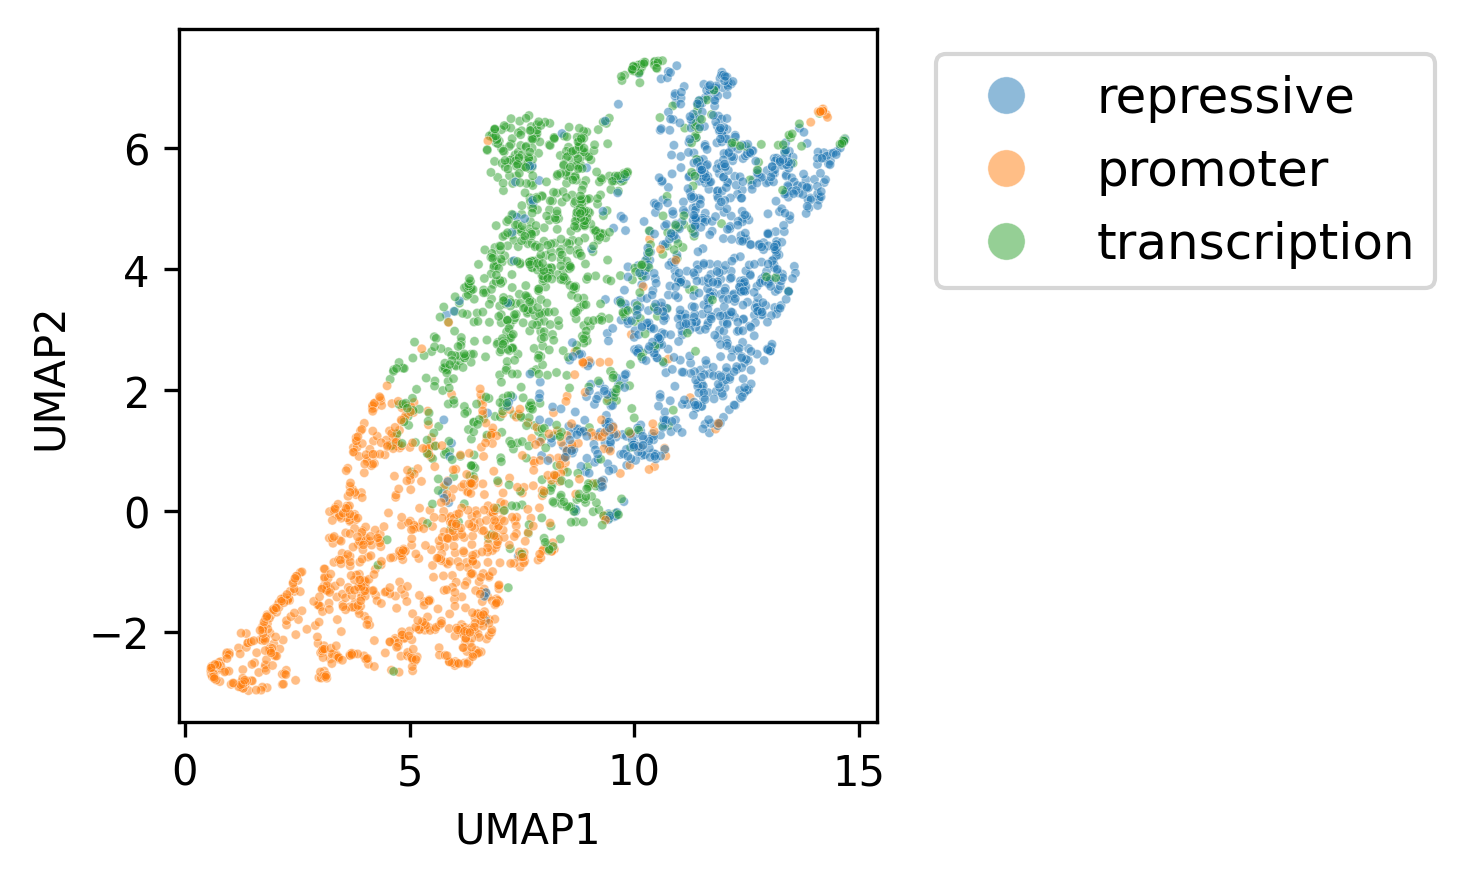

In [6]:
umap_plot(region_emb, overlap_region_bed["anno"], "./output_emb_region_1kb")

### generate gene (promoter region) embeddings

In [7]:
# results.gene_emb_dict: Dict[gene_name, embedding_vector]
# Each embedding is a 768-dimensional vector
results = embed_region(
    gene="ENSG00000170921;TANC2;ENSG00000200997;DPYD;SNORA70;tp53;brd4", # your genes
    odir="./output_emb_genes", # output directory
    genome="hg38",        # Options: "hg38", "mm10"
    resolution="1kb",     # Options: "1kb", "2kb", "4kb", "200bp"
)
gene_emb_dict = results.gene_emb_dict

Using cached region embeddings for gene pooling...

Finished!
Note: All gene names were converted to lowercase for matching.
Gene count summary - requested: 7, matched: 7, not found: 0
Matched gene meta saved to: ./output_emb_genes/overlap_genes_meta.tsv
Gene embeddings saved to: ./output_emb_genes/gene_emb_emb.pkl
Embedding type: general


In [8]:
for key, value in gene_emb_dict.items():
    print(key,value.shape)

ensg00000170921 (768,)
tanc2 (768,)
ensg00000200997 (768,)
dpyd (768,)
snora70 (768,)
tp53 (768,)
brd4 (768,)


### embed_regin (200bp)

In [10]:
results = embed_region(
    region="../data/umap_region_1kb_downsample.bed", # your region
    odir="./output_emb_region_200bp", # output directory
    genome="hg38",        # Options: "hg38", "mm10"
    resolution="200bp",     # Options: "1kb", "2kb", "4kb", "200bp"
)
region_emb=results.region_emb
overlap_region_bed=results.overlap_region_bed

Region summary - total: 3000, overlapping with ChromBERT: 8861 (one region may overlap multiple ChromBERT regions, we keep overlaps with ≥50% coverage of either the ChromBERT bin or the input region), non-overlapping: 3000
Cached region embeddings not found, computing by model...
Your supervised_file does not contain the 'label' column. Please verify whether ground truth column ('label') is required. If it is not needed, you may disregard this message.
Load pretrained ckpt /mnt/Storage/home/chenqianqian/.cache/chrombert/data/checkpoint/hg38_6k_200bp_pretrain.ckpt successfully!


100%|██████████| 2216/2216 [02:27<00:00, 15.01it/s]


Finished!
Focus region summary - total: 3000, overlapping with ChromBERT: 8861, non-overlapping: 3000
Note: It is possible for a single region to overlap multiple ChromBERT regions.
Overlapping regions BED file: ./output_emb_region_200bp/overlap_region.bed
Non-overlapping regions BED file: ./output_emb_region_200bp/no_overlap_region.bed
Region embeddings saved to: ./output_emb_region_200bp/region_emb_emb.npy
Embedding type: general


In [15]:
region_anno = pd.read_csv("../data/umap_region_1kb_downsample.bed",sep="\t",header=None,names=["chrom","start_1kb","end_1kb","build_region_index_1kb","anno"])
overlap_region_bed = overlap_region_bed.merge(region_anno, left_on=["start_input","end_input"], right_on=["start_1kb","end_1kb"], how="left")


/mnt/Storage/home/chenqianqian/miniconda3/envs/chrombert/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


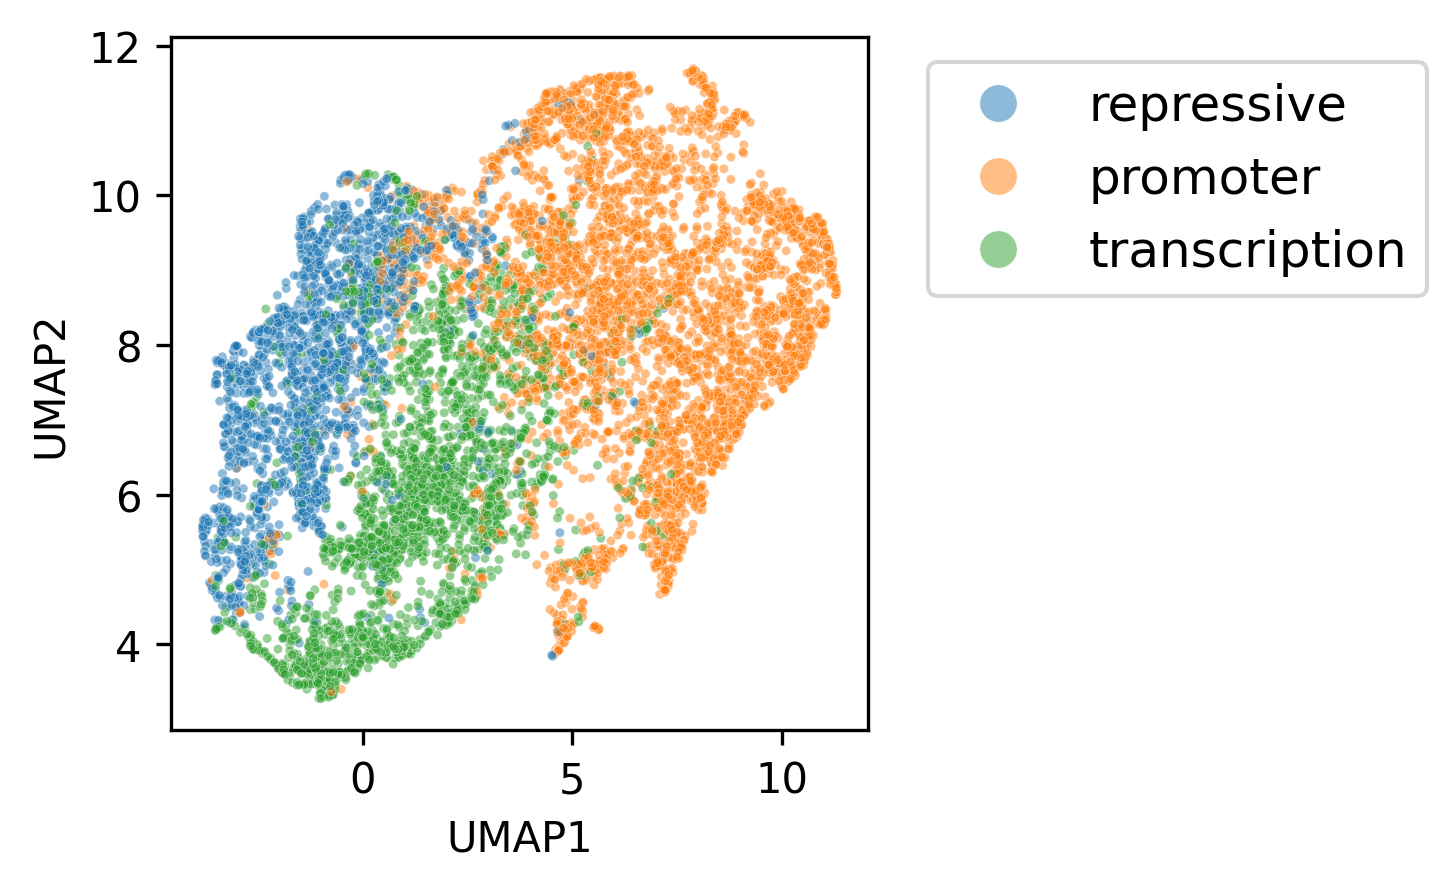

In [16]:
umap_plot(region_emb, overlap_region_bed["anno"], "./output_emb_region_200bp")

### cell-type-specific embeddings

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]='0'

In [2]:
# download myoblast 
import subprocess
if not os.path.exists('../data/myoblast_ENCFF647RNC_peak.bed'):
    cmd = f'wget https://www.encodeproject.org/files/ENCFF647RNC/@@download/ENCFF647RNC.bed.gz -O ../data/myoblast_ENCFF647RNC_peak.bed.gz'
    subprocess.run(cmd, shell=True)
    cmd = f"gzip -d ../data/myoblast_ENCFF647RNC_peak.bed.gz"
    subprocess.run(cmd, shell=True)

# import subprocess
if not os.path.exists('../data/myoblast_ENCFF149ERN_signal.bigwig'):
    cmd = f'wget https://www.encodeproject.org/files/ENCFF149ERN/@@download/ENCFF149ERN.bigWig -O ../data/myoblast_ENCFF149ERN_signal.bigwig'
    subprocess.run(cmd, shell=True)   

In [4]:
!head -n 100 ../data/myoblast_ENCFF647RNC_peak.bed > ../data/myoblast_ENCFF647RNC_peak_100.bed

In [5]:
results_myoblast_specific = embed_region(
    region = "../data/myoblast_ENCFF647RNC_peak_100.bed", # your focus region
    odir = "./output_cell_specific_emb_train", # output directory
    cell_type_bw = "../data/myoblast_ENCFF149ERN_signal.bigwig", # your focus cell-type accessibility data
    cell_type_peak = "../data/myoblast_ENCFF647RNC_peak.bed", # your focus cell-type peak data
    genome = "hg38", # genome
    resolution = "1kb", # resolution
)


Preparing dataset ...
Region summary - total: 373422, overlapping with ChromBERT: 368260 (one region may overlap multiple ChromBERT regions, we keep overlaps with ≥50% coverage of either the ChromBERT bin or the input region), non-overlapping: 7920
Total regions: 324690
Fast mode: downsampling to 20k regions
Fine-tuning cell-specific model...

[Attempt 0/2] seed=55
Load pretrained ckpt /mnt/Storage/home/chenqianqian/.cache/chrombert/data/checkpoint/hg38_6k_1kb_pretrain.ckpt successfully!


/mnt/Storage/home/chenqianqian/miniconda3/envs/chrombert/lib/python3.9/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `SpearmanCorrcoef` will save all targets and predictions in the buffer. For large datasets, this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)
Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loading `train_dataloader` to estimate number of stepping batches.
/mnt/Storage/home/chenqianqian/miniconda3/envs/chrombert/l

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/mnt/Storage/home/chenqianqian/miniconda3/envs/chrombert/lib/python3.9/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:484: Your `val_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.


Training: |          | 0/? [00:00<?, ?it/s]

...

Evaluating the finetuned model performance
Load pretrained ckpt /mnt/Storage/home/chenqianqian/.cache/chrombert/data/checkpoint/hg38_6k_1kb_pretrain.ckpt successfully!
Loading checkpoint from /mnt/Storage2/home/chenqianqian/projects/chrombert/chrombert_tools/ChromBERT-tools/examples/api/output_cell_specific_emb_cistrome/train/try_00_seed_55/lightning_logs/lightning_logs/version_0/checkpoints/epoch=2-step=176.ckpt
Loading from pl module, remove prefix 'model.'
Loading from pl module, replace 'pretrain_model' with 'pretrain_model.chrombert'
Loaded 111/111 parameters


/mnt/Storage/home/chenqianqian/miniconda3/envs/chrombert/lib/python3.9/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `SpearmanCorrcoef` will save all targets and predictions in the buffer. For large datasets, this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


ft_ckpt: /mnt/Storage2/home/chenqianqian/projects/chrombert/chrombert_tools/ChromBERT-tools/examples/api/output_cell_specific_emb_cistrome/train/try_00_seed_55/lightning_logs/lightning_logs/version_0/checkpoints/epoch=2-step=176.ckpt, test_metrics: {'pearsonr': 0.8895615339279175, 'spearmanr': 0.8285167813301086, 'mse': 0.03076925314962864, 'mae': 0.10144855082035065, 'r2': 0.748333793129792}
Attempt metrics: pearsonr=0.8895615339279175
Accepted run (pearsonr=0.8896 >= 0.4).

Finished stage 2: obtained a fine-tuned ChromBERT
Best pearsonr=0.8895615339279175, metrics={'pearsonr': 0.8895615339279175, 'spearmanr': 0.8285167813301086, 'mse': 0.03076925314962864, 'mae': 0.10144855082035065, 'r2': 0.748333793129792, 'ft_ckpt': '/mnt/Storage2/home/chenqianqian/projects/chrombert/chrombert_tools/ChromBERT-tools/examples/api/output_cell_specific_emb_cistrome/train/try_00_seed_55/lightning_logs/lightning_logs/version_0/checkpoints/epoch=2-step=176.ckpt'}
Region summary - total: 100, overlapping 

100%|██████████| 26/26 [00:02<00:00, 12.22it/s]


Finished!
Focus region summary - total: 100, overlapping with ChromBERT: 101, non-overlapping: 0
Note: It is possible for a single region to overlap multiple ChromBERT regions.
Overlapping regions BED file: ./output_cell_specific_emb_cistrome/overlap_region.bed
Non-overlapping regions BED file: ./output_cell_specific_emb_cistrome/no_overlap_region.bed
Region embeddings saved to: ./output_cell_specific_emb_cistrome/region_emb_emb.npy
Embedding type: cell-specific


In [6]:
results_myoblast_specific

ChrombertEmbedRunResult(region_emb=array([[ 1.578125  , -0.00549316,  0.984375  , ..., -0.34179688,
        -0.75390625, -0.6015625 ],
       [ 0.09912109,  0.03295898,  1.359375  , ..., -0.66015625,
        -0.40234375,  0.41601562],
       [ 2.5625    ,  0.37890625,  0.828125  , ..., -0.609375  ,
        -1.1484375 , -0.8828125 ],
       ...,
       [-0.9609375 , -0.63671875,  0.6484375 , ..., -0.76953125,
        -1.140625  ,  0.296875  ],
       [-1.296875  , -0.640625  ,  0.5859375 , ..., -0.48632812,
        -0.9765625 ,  0.5546875 ],
       [-0.859375  , -0.51953125,  0.69921875, ..., -0.55078125,
        -0.5859375 ,  0.6484375 ]], dtype=float32), overlap_region_bed=    chrom    start      end  build_region_index  start_input  end_input
0    chr1   180000   181000                  38       180791     180871
1    chr1   181000   182000                  39       181400     181580
2    chr1   182000   183000                  40       182681     182820
3    chr1   191000   192000  

### load cell-type-specific checkpoint to generate cell-type-specific embeddings

In [1]:
import glob
ft_ckpt_dir = "./output_cell_specific_emb_train/train/**/*.ckpt"

ft_ckpt = glob.glob(ft_ckpt_dir, recursive=True)[0]
ft_ckpt

'./output_cell_specific_emb_train/train/try_00_seed_55/lightning_logs/lightning_logs/version_0/checkpoints/epoch=2-step=176.ckpt'

In [2]:
from chrombert_tools import embed_region

In [3]:
results_myoblast_specific_2 = embed_region(
    region = "../data/myoblast_ENCFF647RNC_peak_100.bed", # your focus region
    odir = "./output_cell_specific_emb_cistrome_2", # output directory
    ft_ckpt = ft_ckpt, # fine-tuned checkpoint
    genome = "hg38", # genome
    resolution = "1kb", # resolution
)


Using provided fine-tuned checkpoint: ./output_cell_specific_emb_cistrome/train/try_00_seed_55/lightning_logs/lightning_logs/version_0/checkpoints/epoch=2-step=176.ckpt
Load pretrained ckpt /mnt/Storage/home/chenqianqian/.cache/chrombert/data/checkpoint/hg38_6k_1kb_pretrain.ckpt successfully!
Loading checkpoint from ./output_cell_specific_emb_cistrome/train/try_00_seed_55/lightning_logs/lightning_logs/version_0/checkpoints/epoch=2-step=176.ckpt
Loading from pl module, remove prefix 'model.'
Loading from pl module, replace 'pretrain_model' with 'pretrain_model.chrombert'
Loaded 111/111 parameters
Region summary - total: 100, overlapping with ChromBERT: 101 (one region may overlap multiple ChromBERT regions, we keep overlaps with ≥50% coverage of either the ChromBERT bin or the input region), non-overlapping: 0
Your supervised_file does not contain the 'label' column. Please verify whether ground truth column ('label') is required. If it is not needed, you may disregard this message.


100%|██████████| 26/26 [00:02<00:00,  9.69it/s]


Finished!
Focus region summary - total: 100, overlapping with ChromBERT: 101, non-overlapping: 0
Note: It is possible for a single region to overlap multiple ChromBERT regions.
Overlapping regions BED file: ./output_cell_specific_emb_cistrome_2/overlap_region.bed
Non-overlapping regions BED file: ./output_cell_specific_emb_cistrome_2/no_overlap_region.bed
Region embeddings saved to: ./output_cell_specific_emb_cistrome_2/region_emb_emb.npy
Embedding type: cell-specific


In [5]:
results_myoblast_specific_2.region_emb

array([[ 1.578125  , -0.00549316,  0.984375  , ..., -0.34179688,
        -0.75390625, -0.6015625 ],
       [ 0.09912109,  0.03295898,  1.359375  , ..., -0.66015625,
        -0.40234375,  0.41601562],
       [ 2.5625    ,  0.37890625,  0.828125  , ..., -0.609375  ,
        -1.1484375 , -0.8828125 ],
       ...,
       [-0.9609375 , -0.63671875,  0.6484375 , ..., -0.76953125,
        -1.140625  ,  0.296875  ],
       [-1.296875  , -0.640625  ,  0.5859375 , ..., -0.48632812,
        -0.9765625 ,  0.5546875 ],
       [-0.859375  , -0.51953125,  0.69921875, ..., -0.55078125,
        -0.5859375 ,  0.6484375 ]], dtype=float32)

In [6]:
results_myoblast_specific_2.ft_ckpt

'./output_cell_specific_emb_cistrome/train/try_00_seed_55/lightning_logs/lightning_logs/version_0/checkpoints/epoch=2-step=176.ckpt'